In [26]:
# typical Python libraries
import numpy as np
import matplotlib.pyplot as plt

# Libraries to read data from internet
import requests

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm

# Hugging Face libraries
from transformers import BertTokenizer, BertModel, AutoTokenizer, AutoModelForCausalLM
#

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create a Classifier model with BERT and load the BERT Classifier State Dicgtionary

In [28]:
class BertForBinaryClassification(nn.Module):
  def __init__(self, num_labels=2):
    super(BertForBinaryClassification, self).__init__()

    # Load the pre-trained BERT model.
    self.bert = BertModel.from_pretrained('bert-base-uncased')

    # classification head that converts the 768-d pooled output into 2 final outputs.
    self.classifier = nn.Linear(768,2)
    self.dropout = nn.Dropout(self.bert.embeddings.dropout.p) # Use the same dropout as BERT's embedding layer (10%)

    # initialize the weights and biases
    nn.init.xavier_uniform_(self.classifier.weight)
    nn.init.zeros_(self.classifier.bias)


  def forward(self, input_ids, attention_mask=None, token_type_ids=None):

    # forward pass through the downloaded (pretrained) BERT
    outputs = self.bert(
      input_ids      = input_ids,
      attention_mask = attention_mask,
      token_type_ids = token_type_ids)

    # extract the pooled output and apply dropout
    pooled_output = self.dropout( outputs.pooler_output )

    # final push through the classification layer.
    logits = self.classifier(pooled_output)
    return logits

In [29]:
# create an instance of the model and load the saved state dictionary
bert = BertForBinaryClassification()
bert.to(device)

bert.load_state_dict(torch.load('/content/bert-classification-model.pt'))

bert.half() # Converts float32 to float16
bert.eval(); # Set the model to evaluation mode
#

In [30]:
# download BERT tokenizer
bertTokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [31]:
# Eleuther's tokenizer
eleuTokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125m")
eleuTokenizer.pad_token_id = eleuTokenizer.encode(' ')[0]

In [32]:
modelAlice = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m").to(device)
modelAlice.eval() # Set the model to evaluation mode

modelEAP = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m").to(device)
modelEAP.eval(); # Set the model to evaluation mode

## Download and enocde text (from "Alice in Wonderland" and Edgar Allen Poe")

In [33]:
# Import texts for "Through the Looking Glass"
text = requests.get('https://www.gutenberg.org/cache/epub/11/pg11.txt').text
aliceTokens = torch.tensor(eleuTokenizer.encode(text),dtype=torch.long)

# Import texts for Edgar Allen Poe"
text = requests.get('https://www.gutenberg.org/cache/epub/2148/pg2148.txt').text
eapTokens = torch.tensor(eleuTokenizer.encode(text),dtype=torch.long)

Token indices sequence length is longer than the specified maximum sequence length for this model (52954 > 2048). Running this sequence through the model will result in indexing errors


# Translate text between Eleuther to BERT

In [34]:
# issue is that they have different tokenizers, so needs to be translated into text and re-tokenized
startingtext = 'Hello, my name is Mike and I like purple.'

# eleuther's tokens:
eleuToks = eleuTokenizer(startingtext)

# bert's tokens
bertToks = bertTokenizer(startingtext)

print(f'Starting text:\n{startingtext}')
print(f'\n\nEleuther tokens:\n{eleuToks}')
print(f"\nDecoded using Eleuther:\n{eleuTokenizer.decode(eleuToks['input_ids'])}")
print(f"\nDecoded using BERT:\n{bertTokenizer.decode(eleuToks['input_ids'])}")

print(f'\n\nBERT tokens:\n{bertToks}')
print(f"\nDecoded using BERT:\n{bertTokenizer.decode(bertToks['input_ids'])}")
print(f"\nDecoded using Eleuther:\n{eleuTokenizer.decode(bertToks['input_ids'])}")

Starting text:
Hello, my name is Mike and I like purple.


Eleuther tokens:
{'input_ids': [15496, 11, 616, 1438, 318, 4995, 290, 314, 588, 14032, 13], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Decoded using Eleuther:
Hello, my name is Mike and I like purple.

Decoded using BERT:
##burgh [unused10] [unused611] ა [unused313] aren [unused285] [unused309] [unused583] jasmine [unused12]


BERT tokens:
{'input_ids': [101, 7592, 1010, 2026, 2171, 2003, 3505, 1998, 1045, 2066, 6379, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Decoded using BERT:
[CLS] hello, my name is mike and i like purple. [SEP]

Decoded using Eleuther:
�lationters 50ills future remember experienceata Republic Land Cl�


In [35]:
# text -> Eleuther tokens -> text -> BERT tokens

# 1) to Eleuther tokens
startingtext = 'Hello, my name is Mike and I like purple.'
eleuToks = eleuTokenizer(startingtext)

# 2) back to text
eleuReconText = eleuTokenizer.decode(eleuToks['input_ids'])

# 3) then to bert tokens
bertToks = bertTokenizer(eleuReconText,add_special_tokens=False)

# 4) show the reconstruction
bertTokenizer.decode(bertToks['input_ids'])

'hello, my name is mike and i like purple.'

In [36]:
# translation functions
def bert2eleu(bertToks):
  b = bertTokenizer.decode(bertToks)
  e = eleuTokenizer.encode(b,add_special_tokens=False)
  return torch.tensor(e).to(device)

def eleu2bert(eleuToks):
  e = eleuTokenizer.decode(eleuToks)
  b = bertTokenizer.encode(e,add_special_tokens=False)
  return torch.tensor(b).to(device)


# test
b2e = bert2eleu(bertToks['input_ids'])
e2b = eleu2bert(b2e)

print(eleuTokenizer.decode(b2e))
print(bertTokenizer.decode(e2b))

hello, my name is mike and i like purple.
hello, my name is mike and i like purple.


# Prepare BERT to classify outputs from Alice and EAP models

In [37]:
seq_length = 128
batch_size = 64

In [38]:
# Function to create batch and labels on GPU

# Tokens to be ignored by BERT
tokens_to_ignore = [
    eleuTokenizer.encode('\n'),
    eleuTokenizer.encode('\t'),
    eleuTokenizer.encode(' '),
    eleuTokenizer.encode('\n\n'),
    eleuTokenizer.encode('\t\t'),
    eleuTokenizer.encode('\t\n'),
    eleuTokenizer.encode('\n\t'),
    [eleuTokenizer.eos_token_id]
]

def bert_batch():

  half_batch = batch_size // 2

  # initialize batch tensor and labels
  batch2classify = torch.zeros((batch_size,seq_length),dtype=torch.long,device=device)
  labels = torch.zeros((batch_size),dtype=torch.long,device=device)

  # generate random starting tokens
  randstarts = torch.randint(0, eleuTokenizer.vocab_size//2, (half_batch,1)).to(device)

  # generate tokens in batch
  out_alice = modelAlice.generate(
      inputs=randstarts,
      min_length=4*seq_length,
      max_length=4*seq_length,
      do_sample=True,
      early_stopping=False,
      eos_token_id=None,
      pad_token_id=eleuTokenizer.pad_token_id,
      bad_words_ids=tokens_to_ignore,
      repetition_penalty=1.3
  )

  out_eap = modelEAP.generate(
      inputs=randstarts,
      min_length=4*seq_length,
      max_length=4*seq_length,
      do_sample=True,
      early_stopping=False,
      eos_token_id=None,
      pad_token_id=eleuTokenizer.pad_token_id,
      bad_words_ids=tokens_to_ignore,
      repetition_penalty=1.3
  )

    # fill the batch tensor
  for i in range(half_batch):

    # first 1/2 is Alice-generated tokens
    outA = eleu2bert(out_alice[i,1:])
    # Ensure outA has length seq_length
    if outA.shape[0] < seq_length:
        # Pad with bertTokenizer.pad_token_id
        padded_outA = torch.cat([outA, torch.full((seq_length - outA.shape[0],), bertTokenizer.pad_token_id, dtype=torch.long, device=device)])
    elif outA.shape[0] > seq_length:
        # Truncate
        padded_outA = outA[:seq_length]
    else:
        padded_outA = outA
    batch2classify[i,:] = padded_outA
    labels[i] = 0  # Label "0" for Alice (was used in training this BERT model)

    # second 1/2 is Edgar-generated tokens
    outE = eleu2bert(out_eap[i,1:])
    # Ensure outE has length seq_length
    if outE.shape[0] < seq_length:
        # Pad with bertTokenizer.pad_token_id
        padded_outE = torch.cat([outE, torch.full((seq_length - outE.shape[0],), bertTokenizer.pad_token_id, dtype=torch.long, device=device)])
    elif outE.shape[0] > seq_length:
        padded_outE = outE[:seq_length]
    else:
        padded_outE = outE
    batch2classify[half_batch+i,:] = padded_outE
    labels[half_batch+i] = 1  # "1" for Edgar

  # remove the large matrices from memory
  del out_alice,out_eap

  return batch2classify, labels

In [39]:
# Test the function
batch2classify,labels = bert_batch()

print(batch2classify.shape)
print(labels.shape)

Token indices sequence length is longer than the specified maximum sequence length for this model (563 > 512). Running this sequence through the model will result in indexing errors


torch.Size([64, 128])
torch.Size([64])


# Train the Generative models and the Classification model

In [40]:
# Define the optimizer functions (loss function is provided by HF transfomer)
optimizer_alice = torch.optim.AdamW(modelAlice.parameters(), lr=1e-5)
optimizer_eap = torch.optim.AdamW(modelEAP.parameters(), lr=1e-5)



In [41]:
# Train the models
num_samples = 121

# Initialize the loss and accuracy functions
loss_alice = np.zeros(num_samples)
loss_eap = np.zeros(num_samples)
acc_bert = np.zeros(num_samples)

for sampli in range(num_samples):

  # get a batch of Alice data
  ix = torch.randint(0, aliceTokens.shape[0] - seq_length, (batch_size,1))
  alice_batch = aliceTokens[ix + torch.arange(seq_length)].to(device)

  # forward pass and get loss
  modelAlice.zero_grad()
  output = modelAlice(alice_batch, labels=alice_batch)
  loss = output.loss

  # Bakc propogatation
  loss.backward()

  # Adjust weights
  optimizer_alice.step()

  # Store the loss in array
  loss_alice[sampli] = loss.item()

  # get a batch for EAP data
  ix = torch.randint(0, eapTokens.shape[0] - seq_length, (batch_size,1))
  eap_batch = eapTokens[ix + torch.arange(seq_length)].to(device)

  # forward pass and get loss
  modelEAP.zero_grad()
  output = modelEAP(eap_batch, labels=eap_batch)
  loss = output.loss

  # Bakc propogatation
  loss.backward()

  # Adjust weights
  optimizer_eap.step()

  # Store the loss in array
  loss_eap[sampli] = loss.item()

  if sampli % 10 == 0:

    # Let the models generate some data

    batch2classify, labels = bert_batch()

    # BERT classification
    with torch.no_grad():
      logits = bert(batch2classify)

    predlabels = torch.argmax(logits,dim=1)
    acc_bert[sampli] = (predlabels == labels).float().mean().item()

    print(f'Sample: {sampli}: Losses(Alice/ EAP): {loss_alice[sampli]:.4f}/{loss_eap[sampli]:.4f}, BERT Accuracy: {acc_bert[sampli]:.4f}')
#

Sample: 0: Losses(Alice/ EAP): 2.8483/2.8415, BERT Accuracy: 0.4844
Sample: 10: Losses(Alice/ EAP): 2.6552/2.7353, BERT Accuracy: 0.5469
Sample: 20: Losses(Alice/ EAP): 2.5116/2.6095, BERT Accuracy: 0.6406
Sample: 30: Losses(Alice/ EAP): 2.4883/2.5959, BERT Accuracy: 0.7188
Sample: 40: Losses(Alice/ EAP): 2.3989/2.5843, BERT Accuracy: 0.7812
Sample: 50: Losses(Alice/ EAP): 2.3834/2.5409, BERT Accuracy: 0.6719
Sample: 60: Losses(Alice/ EAP): 2.3534/2.4611, BERT Accuracy: 0.6094
Sample: 70: Losses(Alice/ EAP): 2.3397/2.5240, BERT Accuracy: 0.6875
Sample: 80: Losses(Alice/ EAP): 2.2313/2.4460, BERT Accuracy: 0.5625
Sample: 90: Losses(Alice/ EAP): 2.2721/2.5015, BERT Accuracy: 0.6719
Sample: 100: Losses(Alice/ EAP): 2.1285/2.4870, BERT Accuracy: 0.5625
Sample: 110: Losses(Alice/ EAP): 2.1138/2.4479, BERT Accuracy: 0.6250
Sample: 120: Losses(Alice/ EAP): 2.0658/2.5015, BERT Accuracy: 0.5312


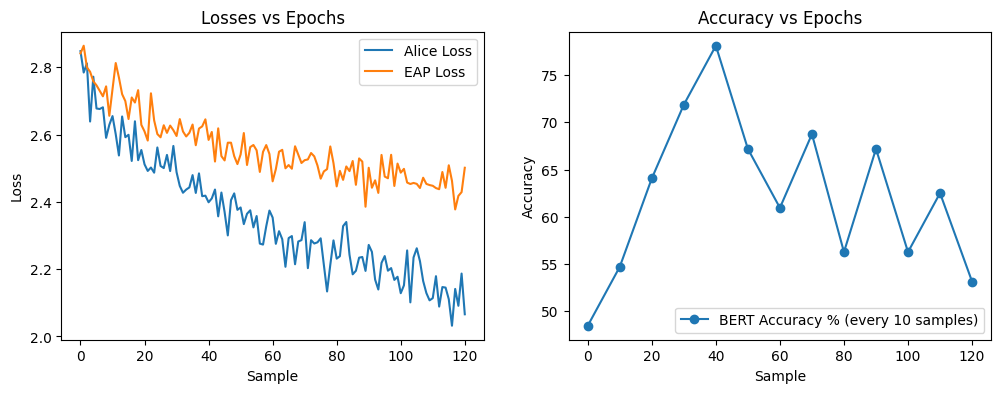

In [42]:
# Visualize the losses and accuracy
_, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(loss_alice, label='Alice Loss')
ax[0].plot(loss_eap, label='EAP Loss')
ax[0].set(xlabel='Sample', ylabel='Loss', title='Losses vs Epochs')
ax[0].legend()

# For BERT accuracy, only plot points where accuracy was recorded (every 10 samples)
x_samples_for_acc = np.arange(0, num_samples, 10)
y_acc_values = acc_bert[::10]

ax[1].plot(x_samples_for_acc, 100 * y_acc_values, 'o-', label='BERT Accuracy % (every 10 samples)')
ax[1].set(xlabel='Sample', ylabel='Accuracy', title='Accuracy vs Epochs')
ax[1].legend()

plt.show();